In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [42]:
df = pd.read_csv(r"C:\Users\Vijay_k943wj6\Desktop\datascience\python\Notes\Data Analyse\Data\BMW sales data (2010-2024) (1).csv")

In [43]:
df.head()

,Model,Year,Region,Color,Fuel_Type,Transmission,Engine_Size_L,Mileage_KM,Price_USD,Sales_Volume,Sales_Classification
0,5 Series,2016,Asia,Red,Petrol,Manual,3.5,151748,98740,8300,High
1,i8,2013,North America,Red,Hybrid,Automatic,1.6,121671,79219,3428,Low
2,5 Series,2022,North America,Blue,Petrol,Automatic,4.5,10991,113265,6994,Low
3,X3,2024,Middle East,Blue,Petrol,Automatic,1.7,27255,60971,4047,Low
4,7 Series,2020,South America,Black,Diesel,Manual,2.1,122131,49898,3080,Low


* ### This is a Data which tell us the Sales report of BMW Company.
* ### It have Global data of BMW sales report from 2010 to 2024.
* ### Finally Which help us to find that Companie's Cars are on High Sales or Not. 

In [4]:
df.isna().sum()

Model                   0
Year                    0
Region                  0
Color                   0
Fuel_Type               0
Transmission            0
Engine_Size_L           0
Mileage_KM              0
Price_USD               0
Sales_Volume            0
Sales_Classification    0
dtype: int64

### The Data Contain No Null Values in the Data set.
### It has 12 Columns and 50000 rows. 

In [5]:
df.columns

Index(['Model', 'Year', 'Region', 'Color', 'Fuel_Type', 'Transmission',
       'Engine_Size_L', 'Mileage_KM', 'Price_USD', 'Sales_Volume',
       'Sales_Classification'],
      dtype='object')

* #### Model - It Explain the Model Name of that Particular Car.
* #### Year - On Which Year the Car was Released.
* #### Region - The Country Name of that Car Released or for Sale.
* #### Color - Which Color of that Car become Saled.
* #### Fuel Type - It Indicates Which fuel type Like Petrol/Diesel Engine.
* #### Transmission - Whether the Car Automatic or Manual.
* #### Engine Size_L - The total volume of all the cylinders in an engine.
* #### Mileage_KM - It indicated the Mileage Claimed by the BMW Company.
* #### Price USD - Which means the Price of that Particular Car.
* #### Sales Volume - The Sales Report in a Volume Based.
* #### Sales_classification - It indicates the Summary of Sales Report whether the Car is Saled High or Low.

In [6]:
df.describe()

,Year,Engine_Size_L,Mileage_KM,Price_USD,Sales_Volume
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,2017.015700,3.247180,100307.203140,75034.600900,5067.514680
std,4.324459,1.009078,57941.509344,25998.248882,2856.767125
min,2010.000000,1.500000,3.000000,30000.000000,100.000000
25%,2013.000000,2.400000,50178.000000,52434.750000,2588.000000
50%,2017.000000,3.200000,100388.500000,75011.500000,5087.000000
75%,2021.000000,4.100000,150630.250000,97628.250000,7537.250000
max,2024.000000,5.000000,199996.000000,119998.000000,9999.000000


* It Represent the Numerical Describe of this Data.
* Year = Minimum Value - 2010, Maximum Value - 2024 (Which Means the datas are From 2010 to 2024).
* Engine_Size_L = Minimum Value - 1.50, Maximum Value - 5 (Which means the Engine size is 1 - 5 ).
* Mileage_KM = Minimum Value - 3, Maximum Value - 19.9 (Which means the Mileage that Claim BMW is 3 to 19 basis of Variant).
* Price_USD = Minimum Value - 30000$, Maximum Value - 119998$ (Which Means the Lowest Price of BMW Car is 3000 and Maximum Highest Price is 119998 in USD).
* Sales_volume = Minimum Value - 100, Maximum Value - 9999 (Which Means the Sales in Volume)

In [7]:
df.describe(include = 'object')

,Model,Region,Color,Fuel_Type,Transmission,Sales_Classification
count,50000,50000,50000,50000,50000,50000
unique,11,6,6,4,2,2
top,7 Series,Asia,Red,Hybrid,Manual,Low
freq,4666,8454,8463,12716,25154,34754


* It Represent the Stastical Column will Describe.
* There are 50000 Rows there
* In Model there are 11 Unique Values there, 7 Series is Top Repeated 4666 Times.
* In Region there are 6 Unique Values there, Asia is Top Repeated which is 8454 Times.
* In Color there are 6 Unique Values there, Red is Top Repeated which is 8463 Times.
* In Fuel_Type there are 4 Unique Values there, Hybrid is Top Repeated which is 12716 Times.
* In Transmission there are 2 Unique Values there, Manual is Top Repeated which is 25154 Times.
* In Sales-Classification there are 2 Unique Values, Low is Top Repeated Which is 34754 Times.

In [8]:
sales_high = df.groupby('Model')['Sales_Volume'].sum().reset_index()
sales_high = sales_high.sort_values(by='Sales_Volume', ascending=True)

In [9]:
sales_high = sales_high.reset_index(drop = True)

In [10]:
sales_high

,Model,Sales_Volume
0,M3,22349694
1,X6,22661986
2,X5,22709749
3,X3,22745529
4,M5,22779688
5,5 Series,23097519
6,i3,23133849
7,3 Series,23281303
8,X1,23406060
9,i8,23423891


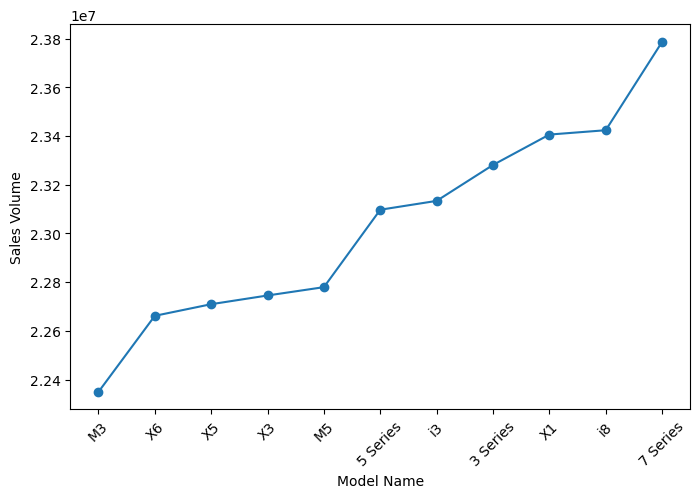

In [12]:
plt.figure(figsize = (8,5))
plt.plot(
    sales_high['Model'],
    sales_high['Sales_Volume'],
    marker = 'o'
)
plt.xticks(rotation = 45)
plt.xlabel('Model Name')
plt.ylabel('Sales Volume')
plt.show()

* #### BMW 7 Series Model Have Higher Sales Compare to Other Models.
* #### Most Lowest Sales have BMW M3 Model.
* #### BMW 5 Series Have Average Sales

In [186]:
region = df.groupby('Region')['Sales_Volume'].mean().reset_index()

In [187]:
region

,Region,Sales_Volume
0,Africa,5036.380952
1,Asia,5083.306955
2,Europe,5106.208063
3,Middle East,5055.131972
4,North America,5087.298020
5,South America,5035.973579


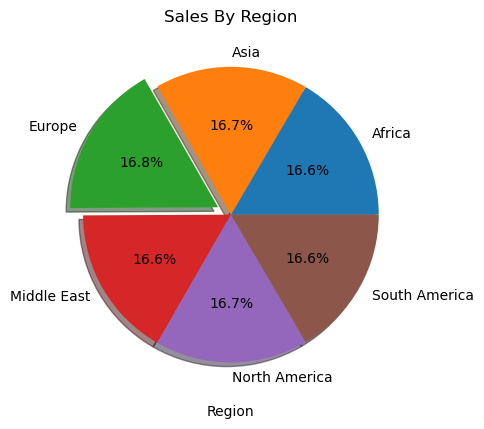

In [190]:
plt.pie(
    region['Sales_Volume'],
    labels = region['Region'],
    autopct = "%1.1f%%",
    explode = [0,0,0.1,0,0,0],
    shadow = True
)
plt.title('Sales By Region')
plt.xlabel('Region')
plt.show()

* #### Europe Region Have Highest Sales.
* #### Rest of the Regions are Almost Same.
* #### Asia and North America Have the Same Sales.
* #### South America, Middle East, Africa have the Lowest among these Data (Slightly Lower).

In [95]:
high_mil = df.groupby('Model')['Mileage_KM'].min().sort_values(ascending = False).reset_index()

In [96]:
high_mil

,Model,Mileage_KM
0,M3,69
1,X3,58
2,i8,57
3,X6,55
4,X1,43
5,M5,42
6,3 Series,36
7,X5,29
8,7 Series,23
9,5 Series,21


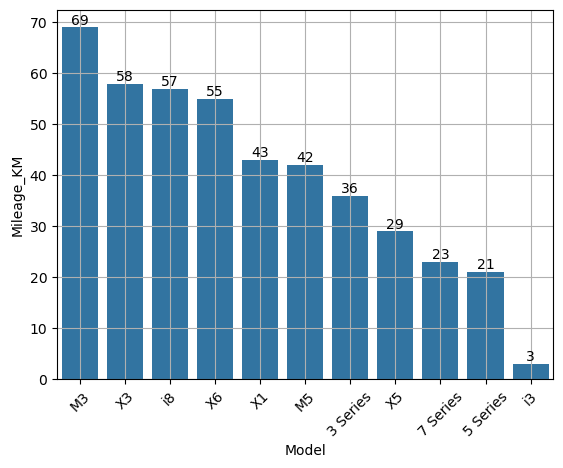

In [98]:
fig = sns.barplot(
    data=high_mil,
    x='Model',
    y='Mileage_KM'
)
for container in fig.containers:
    fig.bar_label(container) 
plt.xticks(rotation=45)
plt.grid()
plt.show()


* #### BMW M3 Series Have the Highest Mileage Segment Car in that Company Around 69 is Getting (Company Claiming).
* #### BMW i3 Series Hve the Lowest Mileage Car, Around 3 Km/Litre (Company Claiming).
* #### Rest of the car have Giving Almost Pretty good Mileage Rating.

In [173]:
model_yr = df.groupby(['Model','Year'])['Sales_Volume'].mean().reset_index()
model_yr

,Model,Year,Sales_Volume
0,3 Series,2010,5198.009464
1,3 Series,2011,5027.651877
2,3 Series,2012,4939.612903
3,3 Series,2013,4844.581940
4,3 Series,2014,5225.295031
...,...,...,...
160,i8,2020,5028.146341
161,i8,2021,5006.176871
162,i8,2022,5137.570968
163,i8,2023,5056.105263


In [174]:
series_3 = model_yr[model_yr['Model']=='3 Series']
series_3

,Model,Year,Sales_Volume
0,3 Series,2010,5198.009464
1,3 Series,2011,5027.651877
2,3 Series,2012,4939.612903
3,3 Series,2013,4844.581940
4,3 Series,2014,5225.295031
5,3 Series,2015,5144.441270
6,3 Series,2016,5235.773700
7,3 Series,2017,4877.465798
8,3 Series,2018,5126.702532
9,3 Series,2019,5016.958763


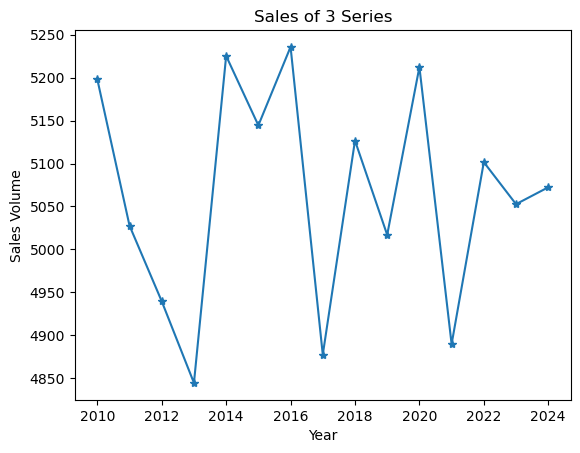

In [212]:
plt.plot(
    series_3['Year']
    ,series_3['Sales_Volume'],
    marker = '*',
)
plt.xlabel('Year')
plt.ylabel('Sales Volume')
plt.title('Sales of 3 Series')
plt.show()

* #### BMW 3 Series Have on the Stage of Up and Down Not a Steady State over the Last 14 years.
* #### On 2010 year 3 Series Sales Become Low and Suddenly Huge Sales Happend.
* #### Then Again the Same Situation Happend, The Sales Had Crashed.
* #### Currently It Stable, But on the Basis of Past Data, there's a Chance to Grow and down 50/50 Chance.

In [227]:
Series_5 = model_yr[model_yr['Model'] == '5 Series']
Series_5

,Model,Year,Sales_Volume
15,5 Series,2010,5020.832776
16,5 Series,2011,5089.403279
17,5 Series,2012,5137.361204
18,5 Series,2013,5081.496622
19,5 Series,2014,5037.831081
20,5 Series,2015,4897.984756
21,5 Series,2016,4891.734694
22,5 Series,2017,5332.983660
23,5 Series,2018,4999.135714
24,5 Series,2019,5079.450794


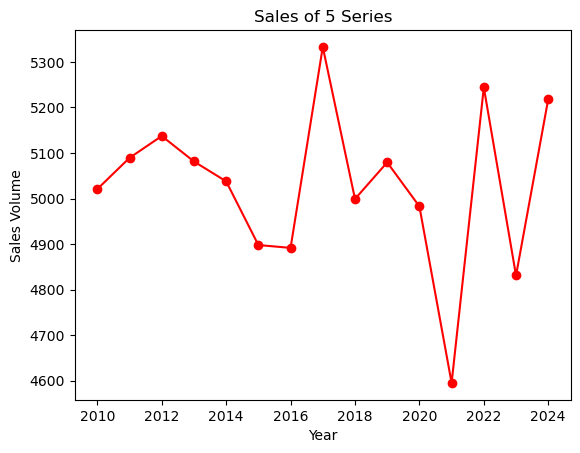

In [228]:
plt.plot(
    Series_5['Year'],
    Series_5['Sales_Volume'],
    color = 'Red',
    marker = 'o'
)
plt.xlabel('Year')
plt.ylabel('Sales Volume')
plt.title('Sales of 5 Series')
plt.show()

* #### 5 Series there's a Stable Sales has going on.
* #### Between 2016-2018 there's Huge Growth in Sales around More than 5300.
* #### But 2020 the Growth become crashed on 2021 they Faced Most Saled Down Period. (It may be because of the Covid Pandemic).
* #### But After 2022 it Become Coming Back.

In [229]:
i8 = model_yr[model_yr['Model'] == 'i8']
i8

,Model,Year,Sales_Volume
150,i8,2010,5147.357595
151,i8,2011,5092.282895
152,i8,2012,4996.500000
153,i8,2013,5205.680645
154,i8,2014,4934.849498
155,i8,2015,5039.868902
156,i8,2016,5359.035714
157,i8,2017,4918.849673
158,i8,2018,5074.006250
159,i8,2019,5122.020690


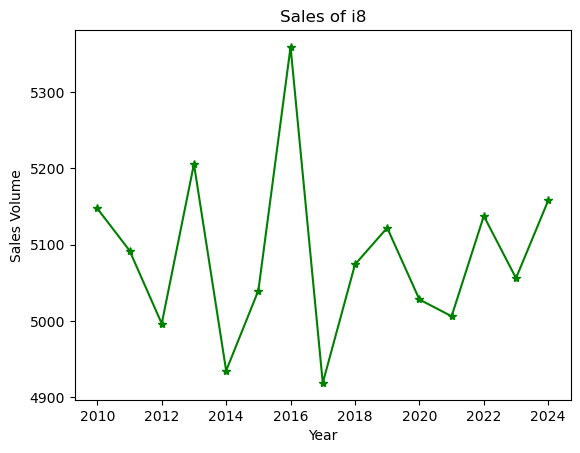

In [230]:
plt.plot(
    i8['Year'],
    i8['Sales_Volume'],
    color = 'Green',
    marker = '*'
)
plt.xlabel('Year')
plt.ylabel('Sales Volume')
plt.title('Sales of i8')
plt.show()

* #### From the Sales Graph of i8 We can see there's a Steadt Path of Sales in i8 Model.
* #### There's a Peak Sales in between 2016.
* #### Unless it become going on a Steady Path.

In [231]:
series7 = model_yr[model_yr['Model'] == '7 Series']
series7

,Model,Year,Sales_Volume
30,7 Series,2010,4975.043011
31,7 Series,2011,5137.391850
32,7 Series,2012,5180.952542
33,7 Series,2013,4916.779935
34,7 Series,2014,5082.184375
35,7 Series,2015,5163.616564
36,7 Series,2016,4905.153846
37,7 Series,2017,5140.930029
38,7 Series,2018,5297.682594
39,7 Series,2019,5026.668990


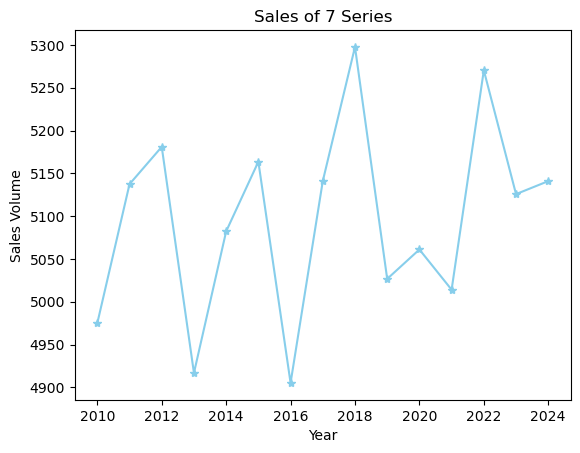

In [232]:
plt.plot(
    series7['Year'],
    series7['Sales_Volume'],
    color = 'skyblue',
    marker = '*'
)
plt.xlabel('Year')
plt.ylabel('Sales Volume')
plt.title('Sales of 7 Series')
plt.show()

* #### The Sales of 7 Series Become High After 2016.
* #### Before that it's like Up and Down (Not Stable).
* #### But After 2016 it becoming High.
* #### after 2016 It was Down high only 1 time on the period of 2020(Pandemic).
* #### After that also it Sales are Growing High.

In [233]:
m5 = model_yr[model_yr['Model'] == 'M5']
m5

,Model,Year,Sales_Volume
60,M5,2010,5145.125806
61,M5,2011,4892.873457
62,M5,2012,4852.270758
63,M5,2013,5219.303226
64,M5,2014,4852.144928
65,M5,2015,5144.246429
66,M5,2016,4969.621094
67,M5,2017,5175.058621
68,M5,2018,5007.965839
69,M5,2019,5284.317460


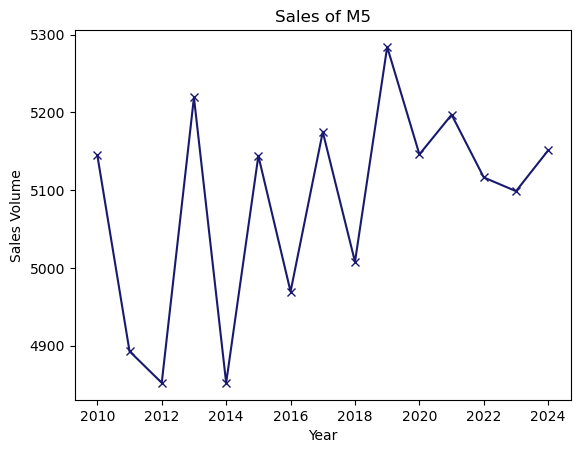

In [234]:
plt.plot(
    m5['Year'],
    m5['Sales_Volume'],
    color = 'midnightblue',
    marker = 'x'
)
plt.xlabel('Year')
plt.ylabel('Sales Volume')
plt.title('Sales of M5')
plt.show()

* #### The Sales of M5 it's Going High Over the Years.
* #### There's a Downfall in 2010.
* #### The Sales of M5 Become Crashed on the Period of 2010 - 2012.
* #### But After that It Growed High in 2013.
* #### Again it Crashed the Saled in 2014.
* #### But Rapidly the Sales Become High and the Graph is on Growing Upwards.
* #### On the Current time Also the Graph is ending on the Upwards, so that the Sales can may be Grow High.

In [244]:
df_price = df.groupby(['Model','Region','Year'])['Price_USD'].max().reset_index()

In [245]:
df_price

,Model,Region,Year,Price_USD
0,3 Series,Africa,2010,118045
1,3 Series,Africa,2011,119070
2,3 Series,Africa,2012,116827
3,3 Series,Africa,2013,117289
4,3 Series,Africa,2014,117890
...,...,...,...,...
985,i8,South America,2020,119651
986,i8,South America,2021,115855
987,i8,South America,2022,115701
988,i8,South America,2023,118502


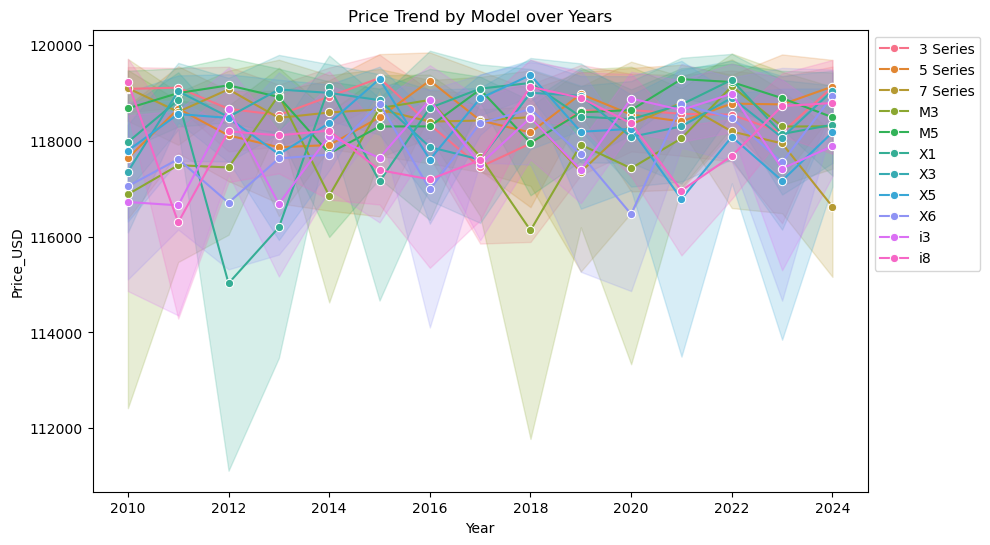

In [257]:
plt.figure(figsize=(10,6))
sns.lineplot(
    data=df_price,
    x='Year',
    y='Price_USD',
    hue='Model',
    marker='o'
)
plt.title("Price Trend by Model over Years")
plt.legend(bbox_to_anchor = (1,1))
plt.show()


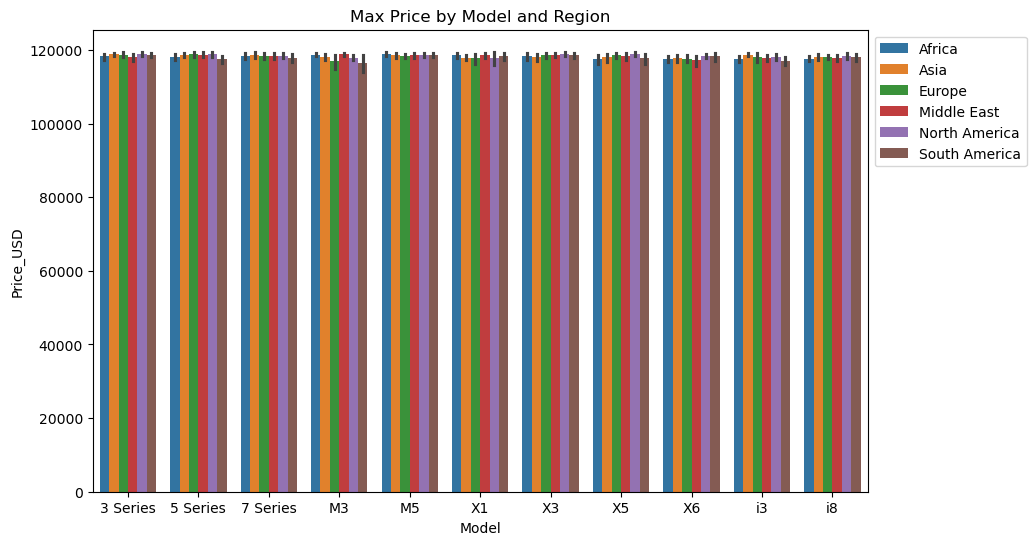

In [258]:
plt.figure(figsize=(10,6))
sns.barplot(
    data=df_price,
    x='Model',
    y='Price_USD',
    hue='Region'
)
plt.title("Max Price by Model and Region")
plt.legend(bbox_to_anchor = (1,1))
plt.show()


* #### The Price of BMW Car Model Over the Region Was Almost Equal there's no High or Low Difference in Price Over the Region.
* #### Almost All Places the Prices are Almost Equal.

In [261]:
series_3 = df_price[df_price['Model'] == '3 Series']

In [262]:
series_3

,Model,Region,Year,Price_USD
0,3 Series,Africa,2010,118045
1,3 Series,Africa,2011,119070
2,3 Series,Africa,2012,116827
3,3 Series,Africa,2013,117289
4,3 Series,Africa,2014,117890
...,...,...,...,...
85,3 Series,South America,2020,117171
86,3 Series,South America,2021,117490
87,3 Series,South America,2022,116714
88,3 Series,South America,2023,118346


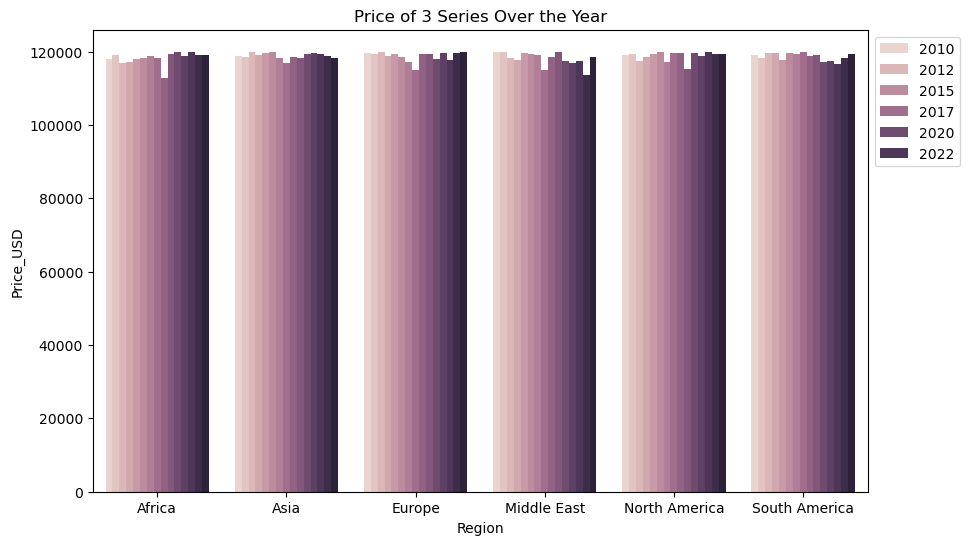

In [268]:
plt.figure(figsize = (10,6))
sns.barplot(
    data = series_3,
    x = 'Region',
    y = 'Price_USD',
    hue = 'Year'
)
plt.title('Price of 3 Series Over the Year')
plt.legend(bbox_to_anchor = (1,1))
plt.show()

* #### On Africa We can See After 2017 there's a Price Hike for 3 Series.
* #### On Asia we can see the Price is Slightly Becoming Low for 3 Series.
* #### On Europe we can see after 2015 the Price was Hiked for 3 Series.
* #### On MiddleEast we can see the Price for 3 Series was Low But then it's Hiked on 2022.
* #### On North America after 2015 the Price was Increased still on Stable Range for 3 Series.
* #### On South America the Price was Increased after 2020.

In [283]:
series_7 = df_price[df_price['Model'] == '7 Series']
series_7

,Model,Region,Year,Price_USD
180,7 Series,Africa,2010,118028
181,7 Series,Africa,2011,118991
182,7 Series,Africa,2012,119253
183,7 Series,Africa,2013,119675
184,7 Series,Africa,2014,117524
...,...,...,...,...
265,7 Series,South America,2020,119715
266,7 Series,South America,2021,118549
267,7 Series,South America,2022,119052
268,7 Series,South America,2023,118815


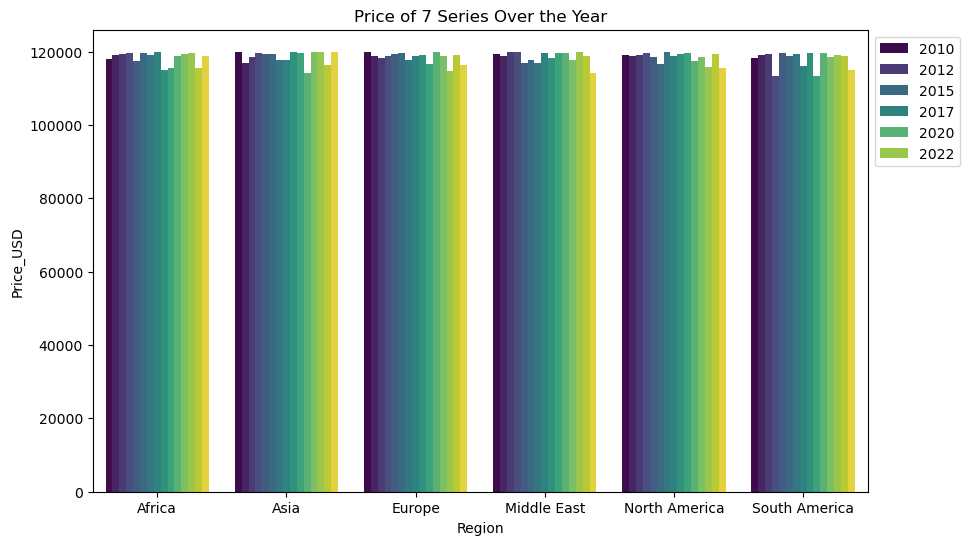

In [284]:
plt.figure(figsize = (10,6))
sns.barplot(
    data = series_7,
    x = 'Region',
    y = 'Price_USD',
    hue = 'Year',
    palette = 'viridis'
)
plt.title('Price of 7 Series Over the Year')
plt.legend(bbox_to_anchor = (1,1))
plt.show()

* #### On Africa We can See After 2015 there's a Price Hike for 7 Series then Again price Decreased on 2020 Again Raised 2022.
* #### On Asia we can see the Price is Become Low in 2017 and Price Hiked for 7 Series.
* #### On Europe we can see Price is Almost Same or Stable in Over all Year for 7 Series.
* #### On Middle we can see the Price for 7 Series was High but it Decreasing.
* #### On North America Price was High but after 2015 price was Becoming Down for 7 Series.
* #### On South America the Price was not Stable Stage Before 2015 After Now it Hiked an Stable for 7 Series.

In [285]:
m5 = df_price[df_price['Model'] == 'M5']
m5

,Model,Region,Year,Price_USD
360,M5,Africa,2010,118016
361,M5,Africa,2011,119638
362,M5,Africa,2012,118648
363,M5,Africa,2013,119192
364,M5,Africa,2014,119623
...,...,...,...,...
445,M5,South America,2020,119440
446,M5,South America,2021,119546
447,M5,South America,2022,119518
448,M5,South America,2023,119600


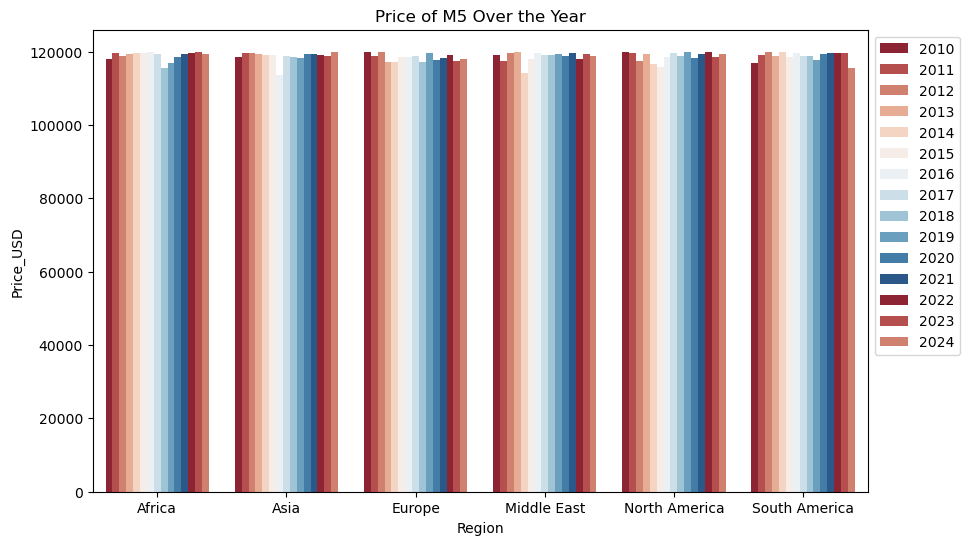

In [286]:
plt.figure(figsize = (10,6))
qual_palette =  sns.color_palette("RdBu", 12)
sns.barplot(
    data = m5,
    x = 'Region',
    y = 'Price_USD',
    hue = 'Year',
    palette = qual_palette
)
plt.title('Price of M5 Over the Year')
plt.legend(bbox_to_anchor = (1,1))
plt.show()

* #### On Africa We can See After 2017 there's a Price Hike for M5 and it Become Stabled.
* #### On Asia we can see the Price for M5 is on the Stabled Stage.
* #### On MiddleEast we can see the Price for M5 is on the Stabled Stage.
* #### On Europe we can see Price for M5 is Almost is on the Stabled Stages.
* #### On North America Price for M5 is Almost is on the Stabled Stages .
* #### On South America the Price for M5 is Almost is on the Stabled Stages.
* #### Overall the Price for m5 is Almost on the Stabled Stage.

In [287]:
X1 = series_7 = df_price[df_price['Model'] == 'X1']
X1

,Model,Region,Year,Price_USD
450,X1,Africa,2010,115634
451,X1,Africa,2011,117606
452,X1,Africa,2012,119343
453,X1,Africa,2013,118322
454,X1,Africa,2014,119988
...,...,...,...,...
535,X1,South America,2020,119215
536,X1,South America,2021,119650
537,X1,South America,2022,119606
538,X1,South America,2023,117986


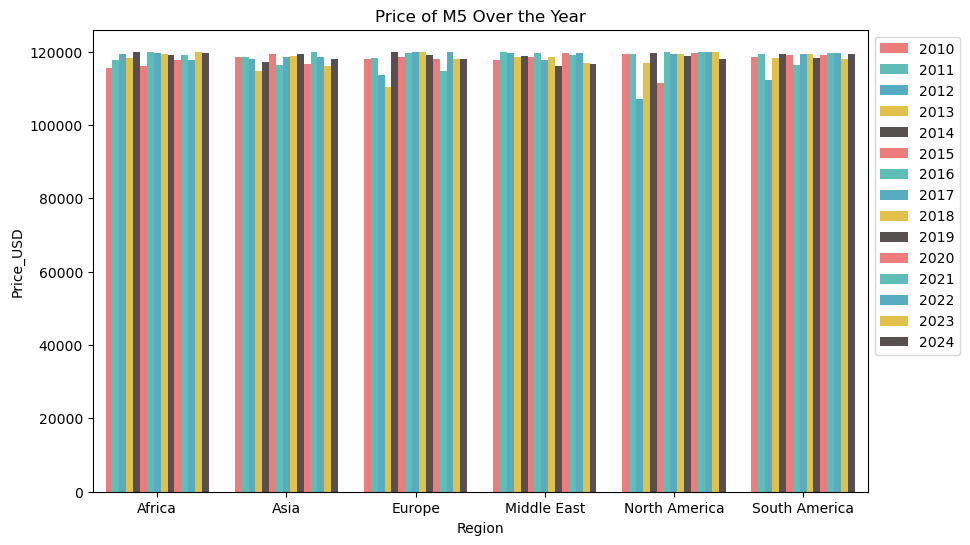

In [289]:
plt.figure(figsize = (10,6))
hex = sns.color_palette(["#FF6B6B", "#4ECDC4", "#45B7D1","#FAD02E", "#594F4F"])
sns.barplot(
    data = X1,
    x = 'Region',
    y = 'Price_USD',
    hue = 'Year',
    palette = hex
)
plt.title('Price of M5 Over the Year')
plt.legend(bbox_to_anchor = (1,1))
plt.show()

* #### On Africa We can See It's on a Stable Stage for X1.
* #### On Asia we can see the Price for X1 is on Down and Up Play.
* #### On MiddleEast we can see the Price for X1 was Low on 2023,2024 but 2025 there's chance to become High (Based on Past data Analysis).
* #### On Europe we can see Price for X1 is Almost as Middle east and We can see the Same Analysis here.
* #### On North America Price for X1 is Almost is on the Stabled Stages .
* #### On South America the Price for X1 is Almost is on the Stabled Stages.

### Overall The Data is showing the Price and Sales of BMW Models. We Can Easily Analysis the Price and Sales over Region and Year. It Also Gives the Year Which Help us to Analyse the Future Price Prediction and Sales Growth Prediction.
### The Data Have The Complete Details of Car's Model like, Mileage in KM, Automatic or Manual Gear Type, etc. Which Help us to analyse Which type of car is Customer Order More, So that we can analyse the Trend and it may Help us to Future Growth.
